In [1]:
!pip install pandas matplotlib seaborn

In [40]:
# Trader Behavior vs Market Sentiment
# PrimeTrade-Assignment
# Author: Krish Choudhary

# 1. Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [41]:
# 2. Load Datasets

sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv", on_bad_lines='skip')

print("Sentiment shape:", sentiment.shape)
print("Trades shape:", trades.shape)

sentiment.head()
trades.head()

Sentiment shape: (2644, 4)
Trades shape: (375937, 16)


/tmp/ipykernel_512/3663447592.py:4: DtypeWarning: Columns (2,3,4,7,9,11,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  trades = pd.read_csv("historical_data.csv", on_bad_lines='skip')


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.0,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630.0,TRUE,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,16.0,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630.0,TRUE,0.0056,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630.0,TRUE,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630.0,TRUE,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630.0,TRUE,0.003055,1.050000e+15,1.730000e+12


In [42]:
# 3. Data Cleaning

# convert sentiment date
sentiment['date'] = pd.to_datetime(sentiment['date'])

# convert trader timestamp
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')

# extract date from timestamp
trades['date'] = trades['Timestamp'].dt.date

# convert sentiment date to date only
sentiment['date_only'] = sentiment['date'].dt.date

# check columns
print(trades.columns)
print(sentiment.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date', 'date_only'], dtype='object')


In [43]:
# 4. Merge Datasets

merged = pd.merge(
    trades,
    sentiment,
    left_on='date',
    right_on='date_only',
    how='inner'
)

print("Merged dataset shape:", merged.shape)

merged.head()

Merged dataset shape: (329778, 22)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Crossed,Fee,Trade ID,Timestamp,date_x,timestamp,value,classification,date_y,date_only
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.0,Buy,0.0,...,TRUE,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed,2024-10-27,2024-10-27
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,16.0,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,...,TRUE,0.0056,4.430000e+14,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed,2024-10-27,2024-10-27
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,...,TRUE,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed,2024-10-27,2024-10-27
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,...,TRUE,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed,2024-10-27,2024-10-27
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,...,TRUE,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,1730007000,74,Greed,2024-10-27,2024-10-27


In [44]:
# 5. Basic Exploration

print("Unique sentiment categories:")
print(merged['classification'].value_counts())

print("\nTrade Direction:")
print(merged['Side'].value_counts())

print("\nCoins traded:")
print(merged['Coin'].value_counts().head())


Unique sentiment categories:
classification
Fear             245701
Greed             66018
Neutral           11071
Extreme Greed      6988
Name: count, dtype: int64

Trade Direction:
Side
SELL    171737
BUY     158041
Name: count, dtype: int64

Coins traded:
Coin
HYPE    123160
@107     51609
BTC      28465
SOL      15512
ETH      15098
Name: count, dtype: int64


In [45]:
# 6. Remove Extreme Outliers

# Convert 'Closed PnL' to numeric
merged['Closed PnL'] = pd.to_numeric(merged['Closed PnL'], errors='coerce')

# remove unrealistic PnL values
merged_clean = merged[merged['Closed PnL'].abs() < 100000]

print("Clean dataset size:", merged_clean.shape)

Clean dataset size: (329775, 22)


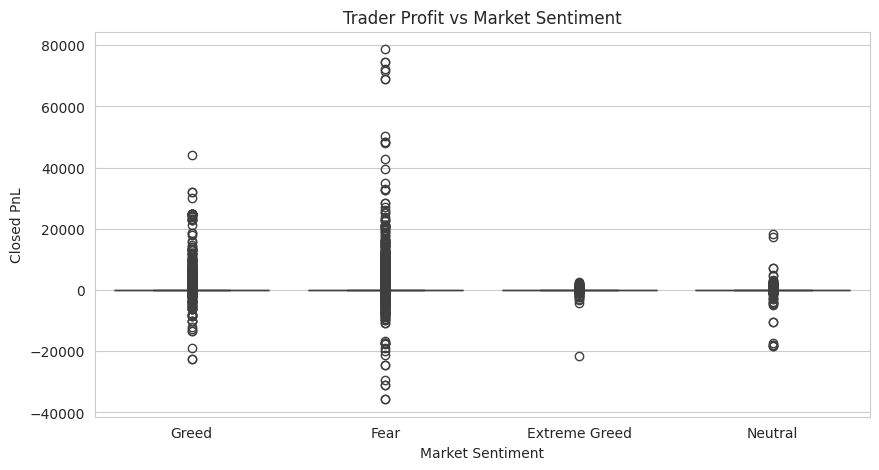

In [46]:
# 7. Profit vs Market Sentiment

plt.figure(figsize=(10,5))

sns.boxplot(
    x='classification',
    y='Closed PnL',
    data=merged_clean
)

plt.title("Trader Profit vs Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")

plt.show()

In [47]:
# 8. Average Profit per Sentiment

profit_sentiment = merged_clean.groupby('classification')['Closed PnL'].mean()

print("\nAverage Profit by Sentiment:")
print(profit_sentiment)


Average Profit by Sentiment:
classification
Extreme Greed    24.527923
Fear             39.574691
Greed            75.776823
Neutral          12.223509
Name: Closed PnL, dtype: float64



Trade Direction Table:
Side               BUY    SELL
classification                
Extreme Greed     3374    3614
Fear            121218  124481
Greed            28169   37848
Neutral           5277    5794


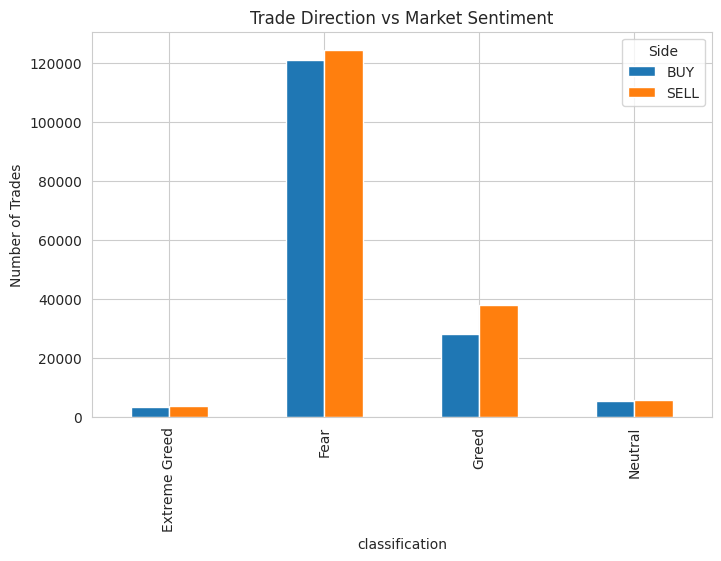

In [48]:
# 9. Trade Direction vs Sentiment

direction_table = pd.crosstab(
    merged_clean['classification'],
    merged_clean['Side']
)

print("\nTrade Direction Table:")
print(direction_table)

direction_table.plot(kind='bar', figsize=(8,5))

plt.title("Trade Direction vs Market Sentiment")
plt.ylabel("Number of Trades")

plt.show()

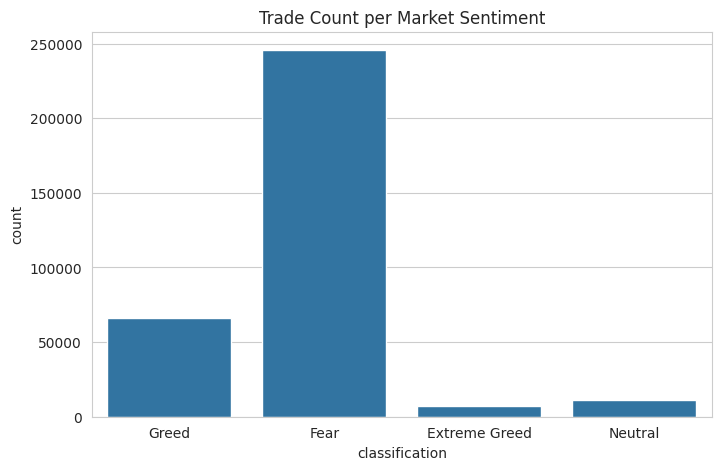

In [49]:
# 10. Number of Trades per Sentiment

plt.figure(figsize=(8,5))

sns.countplot(
    x='classification',
    data=merged_clean
)

plt.title("Trade Count per Market Sentiment")

plt.show()


Top Coins by Trader Profit:
Coin
@107       3.793369e+06
HYPE       3.479675e+06
ETH        1.909132e+06
SOL        1.829661e+06
BTC        7.579963e+05
MELANIA    6.054522e+05
ENA        4.391857e+05
SUI        3.894399e+05
DOGE       2.678519e+05
ZRO        1.821140e+05
Name: Closed PnL, dtype: float64


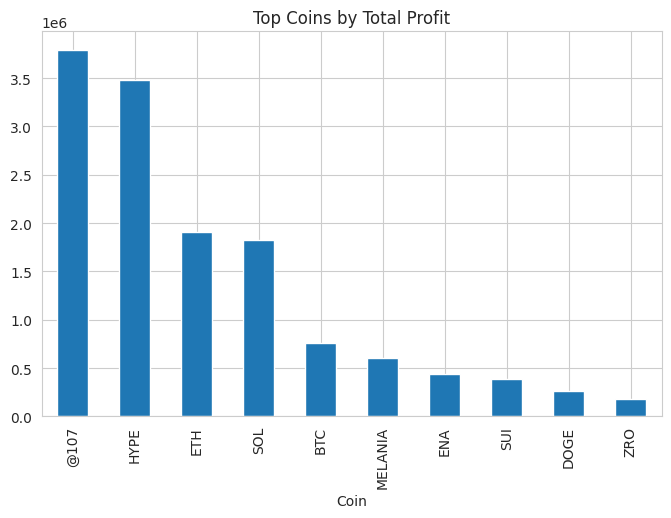

In [50]:
# 11. Profit by Coin

coin_profit = merged_clean.groupby('Coin')['Closed PnL'].sum()

top_coin = coin_profit.sort_values(ascending=False).head(10)

print("\nTop Coins by Trader Profit:")
print(top_coin)

top_coin.plot(kind='bar', figsize=(8,5))

plt.title("Top Coins by Total Profit")

plt.show()


Top Traders by Profit:
Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.567888e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    1.880242e+06
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    1.620780e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.467604e+06
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    1.348536e+06
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    8.516304e+05
0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3    6.742273e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.164904e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    4.035016e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    3.936830e+05
Name: Closed PnL, dtype: float64


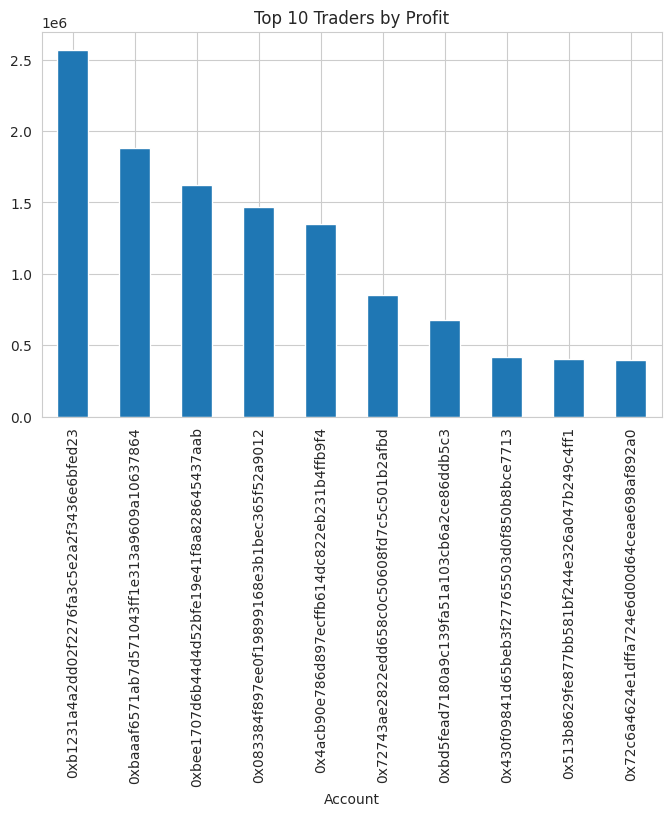

In [51]:
# 12. Top Traders

top_traders = merged_clean.groupby('Account')['Closed PnL'].sum()

top_traders = top_traders.sort_values(ascending=False).head(10)

print("\nTop Traders by Profit:")
print(top_traders)

top_traders.plot(kind='bar', figsize=(8,5))

plt.title("Top 10 Traders by Profit")

plt.show()

In [52]:
# 13. Win Rate Analysis

merged_clean['win'] = merged_clean['Closed PnL'] > 0

win_rate = merged_clean.groupby('classification')['win'].mean()

print("\nTrader Win Rate by Market Sentiment:")
print(win_rate)


Trader Win Rate by Market Sentiment:
classification
Extreme Greed    0.489410
Fear             0.408577
Greed            0.451399
Neutral          0.317316
Name: win, dtype: float64


/tmp/ipykernel_512/2825589516.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_clean['win'] = merged_clean['Closed PnL'] > 0


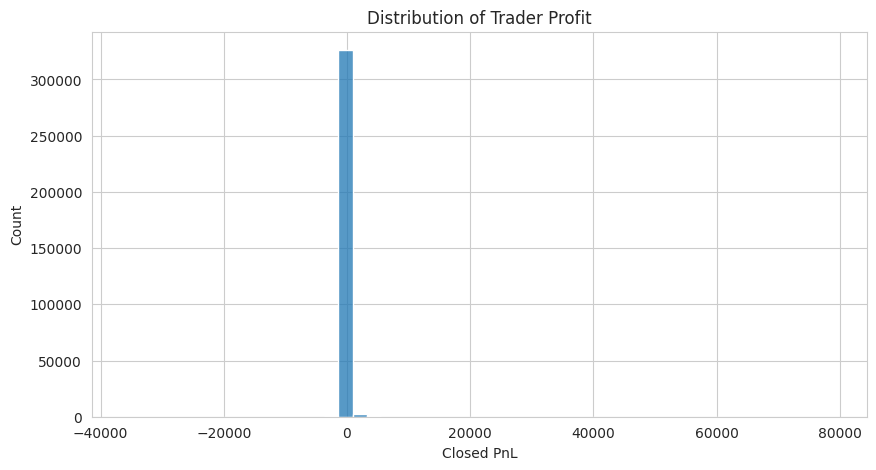

In [53]:
# 14. Profit Distribution

plt.figure(figsize=(10,5))

sns.histplot(
    merged_clean['Closed PnL'],
    bins=50
)

plt.title("Distribution of Trader Profit")

plt.show()


Trading Activity by Sentiment:
classification
Extreme Greed      6988
Fear             245699
Greed             66017
Neutral           11071
Name: Trade ID, dtype: int64


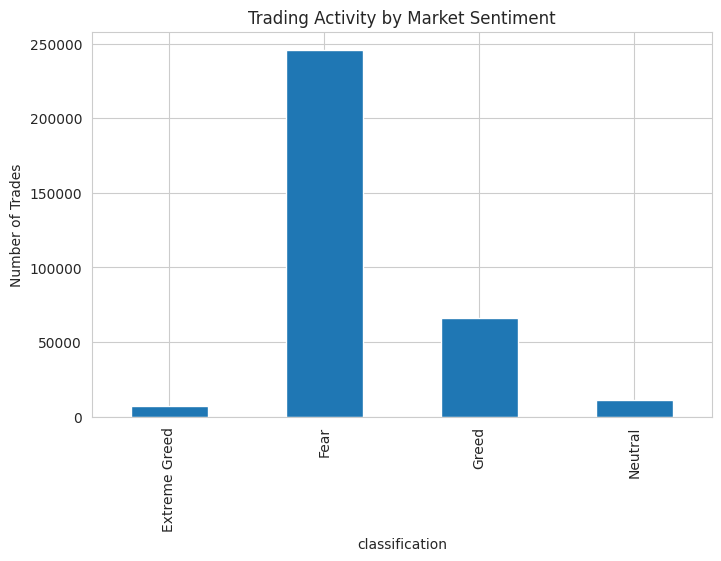

In [55]:
#15. Trading Activity by Market Sentiment

trade_activity = merged_clean.groupby('classification')['Trade ID'].count()

print("\nTrading Activity by Sentiment:")
print(trade_activity)

trade_activity.plot(kind='bar', figsize=(8,5))

plt.title("Trading Activity by Market Sentiment")
plt.ylabel("Number of Trades")

plt.show()


Average Trade Size by Sentiment:
classification
Extreme Greed    5649.865856
Fear             4408.965131
Greed            2575.410573
Neutral          2273.604208
Name: Size USD, dtype: float64


/tmp/ipykernel_512/2670418069.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_clean['Size USD'] = pd.to_numeric(merged_clean['Size USD'], errors='coerce')


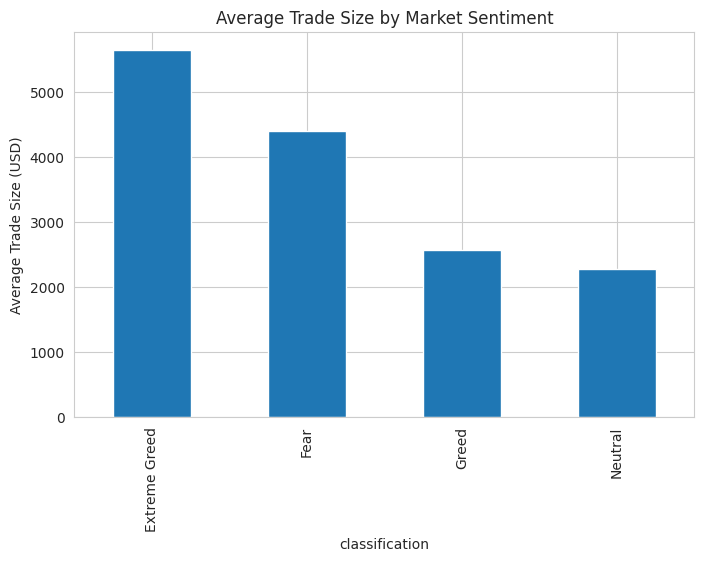

In [57]:
# 16. Average Trade Size by Market Sentiment

merged_clean['Size USD'] = pd.to_numeric(merged_clean['Size USD'], errors='coerce')
avg_trade_size = merged_clean.groupby('classification')['Size USD'].mean()

print("\nAverage Trade Size by Sentiment:")
print(avg_trade_size)

avg_trade_size.plot(kind='bar', figsize=(8,5))

plt.title("Average Trade Size by Market Sentiment")
plt.ylabel("Average Trade Size (USD)")

plt.show()

In [54]:
## FINAL SUMMARY ##

print("\nKey Observations:")

print("1. Trader profitability varies across market sentiment conditions.")
print("2. Greed periods tend to have higher trading activity.")
print("3. Certain coins dominate trader profits.")
print("4. A small group of traders account for a large share of profits.")
print("5. Win rate changes depending on the sentiment phase of the market.")


Key Observations:
1. Trader profitability varies across market sentiment conditions.
2. Greed periods tend to have higher trading activity.
3. Certain coins dominate trader profits.
4. A small group of traders account for a large share of profits.
5. Win rate changes depending on the sentiment phase of the market.
